<a href="https://colab.research.google.com/github/Samprilyanuszalukhu/Sentiment-Analysis-Portal-Pulsa/blob/main/sidang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install Sastrawi tqdm swifter scikit-learn seaborn matplotlib

import pandas as pd
import re
import nltk
from tqdm import tqdm
import swifter
from sklearn.pipeline import Pipeline
import time
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split

import seaborn as sns
from tabulate import tabulate
import matplotlib.pyplot as plt
import numpy as np

tqdm.pandas()
nltk.download('punkt')
nltk.download('stopwords')


try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
except:
    pass


# --- KONFIGURASI ---
FILE_NAME = 'portal_hasil_data.csv'
TEXT_COLUMN_PROCESSED = 'preprocessed'
SCORE_COLUMN = 'score'
RANDOM_SEED = 42
TEST_SIZE = 0.2
K_FOLDS = 10
DISPLAY_MAX_COL_WIDTH = 50
TFIDF_CONFIG = dict(
max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1,2)
)

print("="*80)
print("MULAI ANALISIS SENTIMEN APLIKASI PORTAL PULSA (2 KELAS: POSITIVE & NEGATIVE)")
print("="*80)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 11.4 MB/s eta 0:00:00
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16505 sha256=eaa96fb6cf31aa19de74bd5e9fdbccb6bf0029123a10b7131824037e1bdcb2ae
  Stored in directory: /root/.cache/pip/wheels/d9/31/ff/ff51141a088571a9f672449e5aad5ea8bb35ca5d95ba135f30
Successfully built swifter


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


MULAI ANALISIS SENTIMEN APLIKASI PORTAL PULSA (2 KELAS: POSITIVE & NEGATIVE)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df = pd.read_csv('portal_hasil_data.csv')
df = df[[ 'userName', 'score', 'at', 'content']]

In [ ]:
df = df[[ 'userName', 'score', 'at', 'content']]
print(f"Total review: {len(df)}")

Total review: 4303


In [ ]:
df.head(5)

,userName,score,at,content
0,Pengguna Google,5,2025-10-31 20:02:15,"mantap,udah 3 tahun pake portal pulsa"
1,Pengguna Google,5,2025-10-28 18:55:57,untuk pelayanan tagihan bulanan sejauh ini Uda...
2,Pengguna Google,5,2025-10-22 23:27:34,Aplikasi PORTALPULSA sangat menguntungkan bagi...
3,Pengguna Google,1,2025-10-19 07:54:06,"Sudah 5 tahun jadi member, dan selama itu sela..."
4,Pengguna Google,5,2025-10-14 18:53:37,aplikasi sangat bagus cepat deposit dan pengis...


In [ ]:

try:
    import nltk
    nltk.download('punkt_tab', quiet=True)
except Exception as e:

    pass

factory = StemmerFactory()
stemmer = factory.create_stemmer()
indonesian_stopwords = set(stopwords.words('indonesian') + ['yang', 'dan', 'di', 'ke', 'dari', 'ini', 'untuk', 'dengan', 'pada','juga', 'ada', 'karena', 'sangat', 'sudah', 'masih', 'lagi', 'hanya','saja', 'tidak', 'atau', 'sebagai', 'nya'])

normalization_dict = {
    'gak': 'tidak', 'ga': 'tidak', 'nggak': 'tidak', 'tdk': 'tidak',
    'makasih': 'terima kasih', 'banget': 'sangat', 'cepet': 'cepat',
    'udh': 'sudah', 'ktp': 'ktp', 'nya': '', 'dong': '', 'trs': 'terus',
    'tp': 'tapi', 'topup': 'top up', 'lma': 'lama', 'hlg' : 'hilang',
    'tq' : 'terima kasih', 'tmkasih' : 'terima kasih', 'cpat' : 'cepat',
    'bnus' : 'bonus', 'bsar' : 'besar', 'kcil' : 'kecil', 'kak' : 'kakak',
    'bng' : 'abang', 'pket' : 'paket', 'dta' : 'data', 'mggu' : 'minggu',
    'blan' : 'bulan', 'hrian' : 'harian', 'ok' : 'oke', 'uda' : 'sudah'
}

def apply_casefolding(text):
    """Tahap 1: Case Folding."""
    return str(text).lower()

def apply_cleaning_only(text):
    """Tahap 2: Cleaning Awal (hapus link, angka, repeated chars)."""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def apply_punctuation_removal(text):
    """Tahap 3: Punctuation/Symbol Removal."""
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def apply_tokenizing(text):
    """Tahap 4: Tokenizing."""
    return word_tokenize(text)

def normalize_words(words):
    """Tahap 5: Normalisasi."""
    return [normalization_dict.get(word, word) for word in words]

def remove_stopwords(words):
    """Tahap 6: Stopword Removal."""
    return [word for word in words if word not in indonesian_stopwords and word != '']

def apply_stemming(words):
    """Tahap 7: Stemming."""
    return [stemmer.stem(word) for word in words]


def run_full_pipeline_stepwise(text):
    """Menjalankan seluruh pipeline 7 langkah dan mengembalikan hasilnya."""

    # 1. Casefolding
    cf = apply_casefolding(text)

    # 2. Cleaning Awal
    clean_awal = apply_cleaning_only(cf)

    # 3. Punctuation Removal
    no_punct = apply_punctuation_removal(clean_awal)

    # 4. Tokenizing
    tokens = apply_tokenizing(no_punct)

    # 5. Normalisasi
    normalized = normalize_words(tokens)

    # 6. Stopword Removal
    no_stopwords = remove_stopwords(normalized)

    # 7. Stemming
    stemmed = apply_stemming(no_stopwords)

    result = {

        'Teks_1_CleanAwal': clean_awal,
        'Teks_2_Casefolding': cf,
        #'Teks_3_NoSymbol': no_punct,
        'Teks_3_Tokenize': tokens,
        'Teks_4_Normalize': ' '.join(normalized),
        'Teks_5_NoStopword': ' '.join(no_stopwords),
        'Teks_6_Stemming': ' '.join(stemmed)
    }
    return pd.Series(result)

def full_preprocessing_pipeline(text):
    """Menjalankan seluruh pipeline preprocessing dan mengembalikan hasil akhir (stemmed text) sebagai string tunggal."""
    # 1. Casefolding
    cf = apply_casefolding(text)
    # 2. Cleaning Awal
    clean_awal = apply_cleaning_only(cf)
    # 3. Punctuation Removal
    no_punct = apply_punctuation_removal(clean_awal)
    # 4. Tokenizing
    tokens = apply_tokenizing(no_punct)
    # 5. Normalisasi
    normalized = normalize_words(tokens)
    # 6. Stopword Removal
    no_stopwords = remove_stopwords(normalized)
    # 7. Stemming
    stemmed = apply_stemming(no_stopwords)
    return ' '.join(stemmed)

def truncate_text(text, max_len):
    """Fungsi untuk memotong teks dan menambahkan elipsis jika terlalu panjang"""
    if len(text) > max_len:
        return text[:max_len] + '...'
    return text


df_head = df.head(3)
df_tail = df.tail(3)
ellipsis_row = pd.DataFrame([["..."] * len(df.columns)], columns=df.columns)
df_headtail = pd.concat([df_head, ellipsis_row, df_tail], ignore_index=True)

df_headtail

print("\nMemulai pembuatan Tabel Perbandingan Tahapan Preprocessing (7 Langkah Rinci)...")

intermediate_results = df_headtail['content'].apply(run_full_pipeline_stepwise)

df_elegant_table = pd.concat([df_headtail['content'].rename('Teks Asli'), intermediate_results], axis=1)

MAX_WIDTH =

print(f"\n--- 📝 TABEL HASIL PRA-PEMROSESAN (LEBAR MAKS. {MAX_WIDTH} KARAKTER) ---")


for col in df_elegant_table.columns:
    df_elegant_table[col] = df_elegant_table[col].apply(lambda x: truncate_text(str(x), MAX_WIDTH))

print(df_elegant_table.to_markdown(index=True))


Memulai pembuatan Tabel Perbandingan Tahapan Preprocessing (7 Langkah Rinci)...

--- 📝 TABEL HASIL PRA-PEMROSESAN (LEBAR MAKS. 30 KARAKTER) ---
|    | Teks Asli                         | Teks_1_CleanAwal                  | Teks_2_Casefolding                | Teks_3_Tokenize                   | Teks_4_Normalize                  | Teks_5_NoStopword                 | Teks_6_Stemming                   |
|---:|:----------------------------------|:----------------------------------|:----------------------------------|:----------------------------------|:----------------------------------|:----------------------------------|:----------------------------------|
|  0 | mantap,udah 3 tahun pake porta... | mantap,udah tahun pake portal ... | mantap,udah 3 tahun pake porta... | ['mantap', 'udah', 'tahun', 'p... | mantap udah tahun pake portal ... | mantap udah pake portal pulsa     | mantap udah pake portal pulsa     |
|  1 | untuk pelayanan tagihan bulana... | untuk pelayanan tagihan bulana... |

In [ ]:
TEXT_COLUMN_PROCESSED = 'preprocessed'
TEXT_COLUMN_RAW = 'content'
SCORE_COLUMN = 'score'

try:
    df = pd.read_csv('portal_hasil_data.csv')
    print(f"Dataset berhasil dimuat dari '{'portal_hasil_data.csv'}'. Jumlah data: {len(df)} baris.")
except FileNotFoundError:
    print(f"ERROR: File '{'portal_hasil_data.csv'}' tidak ditemukan. Pastikan file ada.")
    exit()


df = df.dropna(subset=[TEXT_COLUMN_RAW, SCORE_COLUMN])
print(f"Setelah cleaning: {len(df)} baris valid.")

df[TEXT_COLUMN_PROCESSED] = df[TEXT_COLUMN_RAW].apply(full_preprocessing_pipeline)
print("Kolom 'preprocessed' berhasil dibuat.")


Dataset berhasil dimuat dari 'portal_hasil_data.csv'. Jumlah data: 4303 baris.
Setelah cleaning: 4303 baris valid.
Kolom 'preprocessed' berhasil dibuat.



Distribusi Label Sentimen Setelah Penghapusan Netral:
| label    |   count |
|:---------|--------:|
| POSITIVE |    3568 |
| NEGATIVE |     498 |


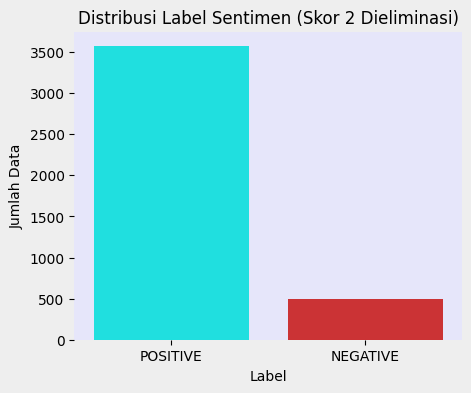

In [ ]:
def map_score_to_sentiment(score):
    score = int(score)

    if score >= 4:
        return 'POSITIVE'
    elif score <= 2:
        return 'NEGATIVE'
    else:
        return 'NEUTRAL'

df['label'] = df[SCORE_COLUMN].apply(map_score_to_sentiment)


df_final = df[df['label'].isin(['POSITIVE', 'NEGATIVE'])].copy()

print("\nDistribusi Label Sentimen Setelah Penghapusan Netral:")
print(df_final['label'].value_counts().to_markdown())


plt.figure(figsize=(5,4), facecolor='#EEEEEE')

custom_palette_hex = ['#00FFFF', '#e41a1c']
sns.countplot(x='label', data=df_final, palette=custom_palette_hex)

ax = plt.gca()
ax.set_facecolor('lavender')

sns.despine(ax=ax, left=True, bottom=True)
plt.title("Distribusi Label Sentimen (Skor 2 Dieliminasi)")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")
plt.show()


In [ ]:

df_negatif = df_final[df_final['label'] == 'NEGATIVE'].copy()
print("==============================================")
print(f"TABEL HASIL LABEL NEGATIF")
print(f"Jumlah Ulasan Negatif Ditemukan: {len(df_negatif)} baris")
print("==============================================")

kolom_tampil = ['score', 'content', 'preprocessed', 'label']

df_negatif[kolom_tampil].head(20)



TABEL HASIL LABEL NEGATIF
Jumlah Ulasan Negatif Ditemukan: 498 baris


,score,content,preprocessed,label
3,1,"Sudah 5 tahun jadi member, dan selama itu sela...",member puas nyaman kecewa batas saldo deposit ...,NEGATIVE
7,1,isi pulsa lama masuk,isi pulsa masuk,NEGATIVE
8,1,sekarang udh ada pembatasan saldo 30% setiap d...,batas saldo deposit hadeh mah jual konter bata...,NEGATIVE
13,1,"awalnya bagus, tapi skrg aneh ada pembatasan d...",bagus skrg aneh batas dgn alas cuci uang konsu...,NEGATIVE
16,1,"makin kesini pelayanan tidak memuaskan, sering...",kesini layan muas delay bukti trans top up pul...,NEGATIVE
17,1,"Aplikasi penipu, di aplikasi tertulis pembelia...",aplikasi tipu aplikasi tulis beli paket gb bel...,NEGATIVE
20,1,Aplikasi paling buruk. Isi saldo sampai 1 jam ...,aplikasi buruk isi saldo jam masuk rekom lh ap...,NEGATIVE
23,1,"Pikir"" lagi buat yang mau pakai Portal pengala...",pikir pakai portal alam x kjadian isi pulsa la...,NEGATIVE
30,1,setiap tahun semakin turun kualitasnya,turun kualitas,NEGATIVE
44,2,kurang bagus aplikasinya langsung topup langsu...,bagus aplikasi langsung top up langsung gc apl...,NEGATIVE


In [ ]:

df_positif = df_final[df_final['label'] == 'POSITIVE'].copy()

print("==============================================")
print(f"TABEL HASIL LABEL POSITIF")
print(f"Jumlah Ulasan Negatif Ditemukan: {len(df_positif)} baris")
print("==============================================")

kolom_tampil = ['score', 'content', 'preprocessed', 'label']

df_positif[kolom_tampil].head(20)



TABEL HASIL LABEL POSITIF
Jumlah Ulasan Negatif Ditemukan: 3568 baris


,score,content,preprocessed,label
0,5,"mantap,udah 3 tahun pake portal pulsa",mantap udah pake portal pulsa,POSITIVE
1,5,untuk pelayanan tagihan bulanan sejauh ini Uda...,layan tagih bulan oke cuman opsi tambah bayar ...,POSITIVE
2,5,Aplikasi PORTALPULSA sangat menguntungkan bagi...,aplikasi portalpulsa untung terima kasih aplik...,POSITIVE
4,5,aplikasi sangat bagus cepat deposit dan pengis...,aplikasi bagus cepat deposit isi pulsa,POSITIVE
5,5,"top markotop. jadi member sdah lebih 5tahun, b...",top markotop member sdah ngerti kalo portalpul...,POSITIVE
6,5,mantap,mantap,POSITIVE
9,5,harga pulsa murah dan cepat masuknya,harga pulsa murah cepat masuk,POSITIVE
10,5,ok terima kasih responsnya,oke terima kasih respons,POSITIVE
11,5,senang menggunakan aplikasi ini,senang aplikasi,POSITIVE
12,5,sangat mudah,mudah,POSITIVE


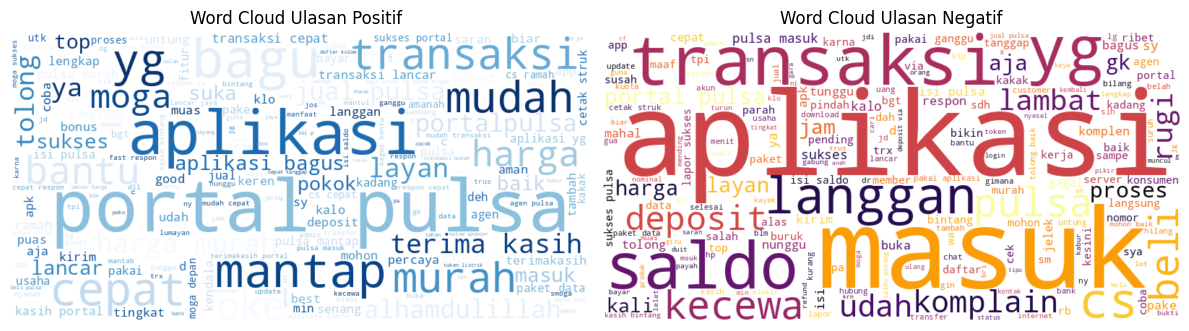

In [ ]:
from wordcloud import WordCloud # Import WordCloud

positive_text = ' '.join(df[df['label'] == 'POSITIVE'][TEXT_COLUMN_PROCESSED])
negative_text = ' '.join(df[df['label'] == 'NEGATIVE'][TEXT_COLUMN_PROCESSED])

wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(positive_text)
wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='inferno').generate(negative_text)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(wc_pos, interpolation='bilinear')
plt.title('Word Cloud Ulasan Positif ')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(wc_neg, interpolation='bilinear')
plt.title('Word Cloud Ulasan Negatif')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# =============================
# 6. SPLIT DATA
# =============================
X = df_final["preprocessed"].values
y = df_final["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")


Train: 3252 | Test: 814


In [ ]:
X_data_for_cv = X_train
y_data_for_cv = y_train


In [ ]:
tfidf_dim = TfidfVectorizer(**TFIDF_CONFIG)
tfidf_matrix_dim = tfidf_dim.fit_transform(X_train)

print("\n" + "="*60)
print("="*60)
print(f"Jumlah Baris (Dokumen): {tfidf_matrix_dim.shape[0]}")
print(f"Jumlah Kolom (Fitur/Kata): {tfidf_matrix_dim.shape[1]}")
print(f"Total Elemen Matriks: {tfidf_matrix_dim.shape[0] * tfidf_matrix_dim.shape[1]}")
print("="*60)
print("10 Contoh Nama Fitur:")
print(tfidf_dim.get_feature_names_out()[:10])


Jumlah Baris (Dokumen): 3252
Jumlah Kolom (Fitur/Kata): 3667
Total Elemen Matriks: 11925084
10 Contoh Nama Fitur:
['aamiin' 'abis' 'ad' 'ada' 'adaa' 'adain' 'adain bayar' 'adakan' 'adm'
 'admin']


In [ ]:
import pandas as pd
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1,2)
)
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

X_full_tfidf = tfidf.fit_transform(X)
y_full = y

print(f"\nDimensi fitur TF-IDF: Train {X_train_tfidf.shape}, Test {X_test_tfidf.shape}")

feature_names = tfidf.get_feature_names_out()
df_tfidf_matrix = pd.DataFrame(
    X_train_tfidf[:5, :10].toarray(),
    columns=feature_names[:10]
)

print(df_tfidf_matrix.to_markdown())


Dimensi fitur TF-IDF: Train (3252, 3667), Test (814, 3667)
|    |   aamiin |   abis |   ad |   ada |   adaa |   adain |   adain bayar |   adakan |   adm |   admin |
|---:|---------:|-------:|-----:|------:|-------:|--------:|--------------:|---------:|------:|--------:|
|  0 |        0 |      0 |    0 |     0 |      0 |       0 |             0 |        0 |     0 |       0 |
|  1 |        0 |      0 |    0 |     0 |      0 |       0 |             0 |        0 |     0 |       0 |
|  2 |        0 |      0 |    0 |     0 |      0 |       0 |             0 |        0 |     0 |       0 |
|  3 |        0 |      0 |    0 |     0 |      0 |       0 |             0 |        0 |     0 |       0 |
|  4 |        0 |      0 |    0 |     0 |      0 |       0 |             0 |        0 |     0 |       0 |


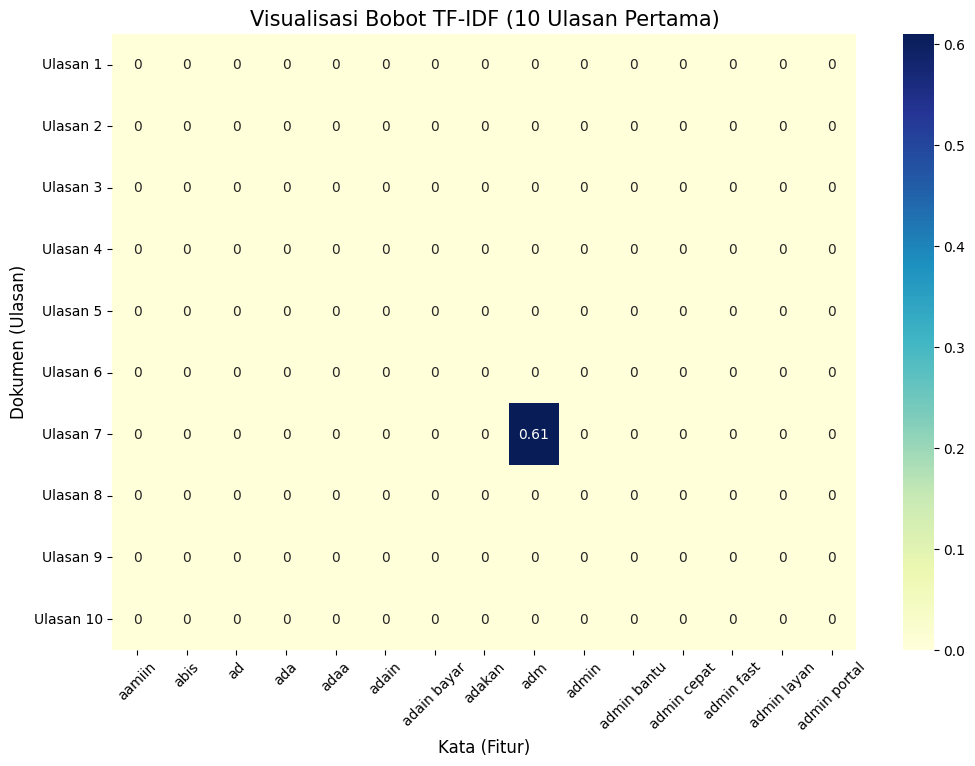

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sample_matrix = tfidf_matrix_dim[:10, :15].toarray()
sample_features = tfidf_dim.get_feature_names_out()[:15]
plt.figure(figsize=(12, 8))
sns.heatmap(sample_matrix, annot=True, cbar=True,
            xticklabels=sample_features,
            yticklabels=[f"Ulasan {i+1}" for i in range(10)],
            cmap="YlGnBu") # Warna kuning-hijau-biru yang profesional

plt.title("Visualisasi Bobot TF-IDF (10 Ulasan Pertama)", fontsize=15)
plt.xlabel("Kata (Fitur)", fontsize=12)
plt.ylabel("Dokumen (Ulasan)", fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [ ]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(max_iter=10000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=RANDOM_SEED)
}

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)


all_fold_accuracies = {}

In [ ]:
from sklearn.base import clone
overall_results_per_model = []

for model_name, model in models.items():
    print("\n" + "="*60)
    print(f"Memproses model: {model_name}")
    print("="*60)


    per_fold_rows = []
    fold_idx = 0

    for train_idx, val_idx in skf.split(X_data_for_cv, y_data_for_cv):
        fold_idx += 1
        X_train_fold = X_data_for_cv[train_idx]
        y_train_fold = y_data_for_cv[train_idx]
        X_val_fold = X_data_for_cv[val_idx]
        y_val_fold = y_data_for_cv[val_idx]

        pipeline = Pipeline([
            ("tfidf", TfidfVectorizer(**TFIDF_CONFIG)),
              ("clf", clone(model))


        ])

        pipeline.fit(X_train_fold, y_train_fold)
        y_pred_fold = pipeline.predict(X_val_fold)

        acc = accuracy_score(y_val_fold, y_pred_fold)
        prec_w = precision_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0)
        rec_w = recall_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0)
        f1_w = f1_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0)

        total_fold = len(y_val_fold)
        pred_negative = int((y_pred_fold == 'NEGATIVE').sum())
        pred_positive = int((y_pred_fold == 'POSITIVE').sum())
        labels_order = ['NEGATIVE', 'POSITIVE']
        cm = confusion_matrix(y_val_fold, y_pred_fold, labels=labels_order)

        true_negative = int(cm[0,0])
        true_positive = int(cm[1,1])

        per_fold_rows.append({
            'Fold': fold_idx,
            'Total': total_fold,
            'Pred_POS': pred_positive,
            'Pred_NEG': pred_negative,
            'True_POS': true_positive,
            'True_NEG': true_negative,
            'Accuracy': round(acc, 4),
            'Precision_weighted': round(prec_w, 4),
            'Recall_weighted': round(rec_w, 4),
            'F1_weighted': round(f1_w, 4)
        })

        print(f"Fold {fold_idx:2d} | Total {total_fold:4d} | Pred_POS {pred_positive:3d} | Pred_NEG {pred_negative:3d} | Acc {acc:.4f} | F1 {f1_w:.4f}")

    df_per_model = pd.DataFrame(per_fold_rows)


    all_fold_accuracies[model_name] = df_per_model['Accuracy'].tolist()

    avg_row = {
        'Fold': 'Average',
        'Total': df_per_model['Total'].sum(),
        'Pred_NEG': df_per_model['Pred_NEG'].sum(),
        'Pred_POS': df_per_model['Pred_POS'].sum(),
        'True_NEG': df_per_model['True_NEG'].sum(),
        'True_POS': df_per_model['True_POS'].sum(),
        'Accuracy': round(df_per_model['Accuracy'].mean(), 4),
        'Precision_weighted': round(df_per_model['Precision_weighted'].mean(), 4),
        'Recall_weighted': round(df_per_model['Recall_weighted'].mean(), 4),
        'F1_weighted': round(df_per_model['F1_weighted'].mean(), 4)
    }
    df_per_model = pd.concat([df_per_model, pd.DataFrame([avg_row])], ignore_index=True)

    csv_name = f"hasil_cv_{model_name}.csv"
    df_per_model.to_csv(csv_name, index=False)
    print(f"\nCSV per-fold untuk model {model_name} disimpan sebagai: {csv_name}")

    pd.set_option('display.max_colwidth', DISPLAY_MAX_COL_WIDTH)
    print("\nTabel detail per-fold (ditampilkan):")
    try:
        print(df_per_model.to_markdown(index=False))
    except Exception:
        print(df_per_model)

    overall_results_per_model.append({
        'Algoritma': model_name,
        'CV_Accuracy': avg_row['Accuracy'],
        'CV_Precision': avg_row['Precision_weighted'],
        'CV_Recall': avg_row['Recall_weighted'],
        'CV_F1-Score': avg_row['F1_weighted'],
        'Time': 'N/A'
    })
    time.sleep(0.5)

print("\nSemua model selesai. CSV per-model telah disimpan dan tabel per-fold ditampilkan di atas.")
print("- Setiap CSV berisi baris per fold (Fold 1..10) + baris Average di akhir.")
print("- Untuk bukti manual, dospem dapat membuka CSV dan mengecek Pred_POS / Pred_NEG tiap fold.")


Memproses model: Naive Bayes
Fold  1 | Total  326 | Pred_POS 322 | Pred_NEG   4 | Acc 0.8896 | F1 0.8477
Fold  2 | Total  326 | Pred_POS 321 | Pred_NEG   5 | Acc 0.8926 | F1 0.8540
Fold  3 | Total  325 | Pred_POS 322 | Pred_NEG   3 | Acc 0.8892 | F1 0.8450
Fold  4 | Total  325 | Pred_POS 316 | Pred_NEG   9 | Acc 0.9077 | F1 0.8811
Fold  5 | Total  325 | Pred_POS 321 | Pred_NEG   4 | Acc 0.8892 | F1 0.8472
Fold  6 | Total  325 | Pred_POS 318 | Pred_NEG   7 | Acc 0.8862 | F1 0.8493
Fold  7 | Total  325 | Pred_POS 324 | Pred_NEG   1 | Acc 0.8738 | F1 0.8179
Fold  8 | Total  325 | Pred_POS 320 | Pred_NEG   5 | Acc 0.8923 | F1 0.8535
Fold  9 | Total  325 | Pred_POS 317 | Pred_NEG   8 | Acc 0.8831 | F1 0.8472
Fold 10 | Total  325 | Pred_POS 321 | Pred_NEG   4 | Acc 0.8892 | F1 0.8472

CSV per-fold untuk model Naive Bayes disimpan sebagai: hasil_cv_Naive Bayes.csv

Tabel detail per-fold (ditampilkan):
| Fold    |   Total |   Pred_POS |   Pred_NEG |   True_POS |   True_NEG |   Accuracy |   Pr

In [ ]:
cv_df = pd.DataFrame(overall_results_per_model)
cv_df = cv_df.sort_values("CV_F1-Score", ascending=False)

print("\nHASIL CROSS VALIDATION")
print(cv_df.to_markdown(index=False))



HASIL CROSS VALIDATION
| Algoritma     |   CV_Accuracy |   CV_Precision |   CV_Recall |   CV_F1-Score | Time   |
|:--------------|--------------:|---------------:|------------:|--------------:|:-------|
| Linear SVM    |        0.9166 |         0.912  |      0.9166 |        0.9122 | N/A    |
| Decision Tree |        0.8964 |         0.8845 |      0.8964 |        0.8857 | N/A    |
| Random Forest |        0.901  |         0.8902 |      0.901  |        0.8804 | N/A    |
| Naive Bayes   |        0.8893 |         0.8826 |      0.8893 |        0.849  | N/A    |
| KNN           |        0.877  |         0.8075 |      0.877  |        0.8245 | N/A    |


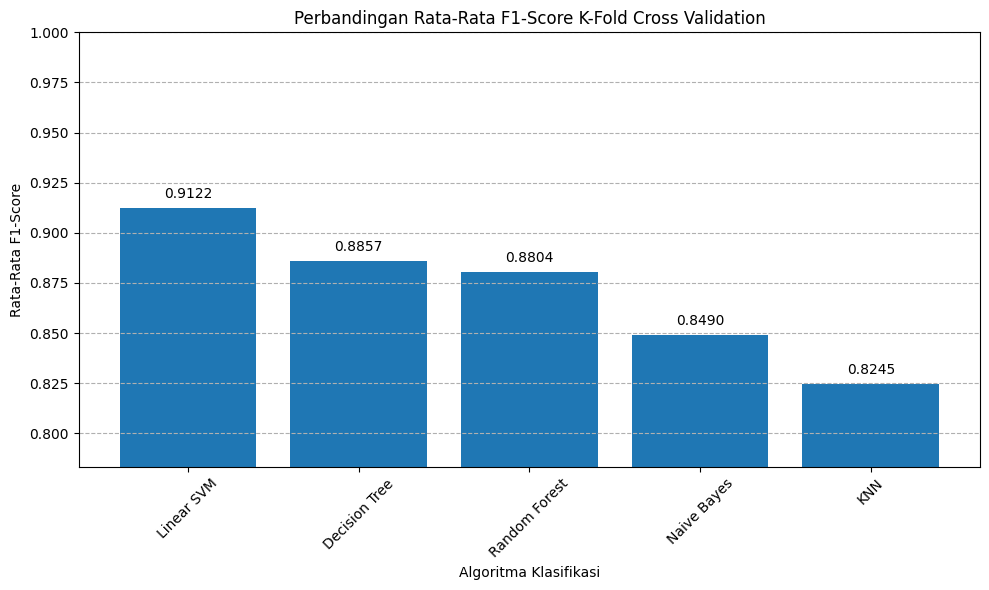

In [ ]:
import matplotlib.pyplot as plt

# Ambil data
algoritma = cv_df['Algoritma']
cv_f1 = cv_df['CV_F1-Score']

plt.figure(figsize=(10, 6))
plt.bar(algoritma, cv_f1)

for i, v in enumerate(cv_f1):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center')

plt.title('Perbandingan Rata-Rata F1-Score K-Fold Cross Validation')
plt.xlabel('Algoritma Klasifikasi')
plt.ylabel('Rata-Rata F1-Score')
plt.ylim(min(cv_f1) * 0.95, 1.0)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_results = []

for name, estimator in models.items():
    print("\n" + "="*60)
    print(f"EVALUASI TEST SET: {name}")
    print("="*60)

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_CONFIG)),
          ("clf", estimator)
    ])

    pipeline.fit(X_train, y_train)
    y_test_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

    print(classification_report(y_test, y_test_pred))

    test_results.append({
        "Algoritma": name,
        "Test_Accuracy": round(acc, 4),
        "Test_Precision": round(prec, 4),
        "Test_Recall": round(rec, 4),
        "Test_F1-Score": round(f1, 4)
    })



EVALUASI TEST SET: Naive Bayes
              precision    recall  f1-score   support

    NEGATIVE       1.00      0.11      0.20       100
    POSITIVE       0.89      1.00      0.94       714

    accuracy                           0.89       814
   macro avg       0.94      0.56      0.57       814
weighted avg       0.90      0.89      0.85       814


EVALUASI TEST SET: Linear SVM
              precision    recall  f1-score   support

    NEGATIVE       0.75      0.67      0.71       100
    POSITIVE       0.95      0.97      0.96       714

    accuracy                           0.93       814
   macro avg       0.85      0.82      0.84       814
weighted avg       0.93      0.93      0.93       814


EVALUASI TEST SET: Random Forest
              precision    recall  f1-score   support

    NEGATIVE       0.82      0.33      0.47       100
    POSITIVE       0.91      0.99      0.95       714

    accuracy                           0.91       814
   macro avg       0.87      0.

In [ ]:
df_test_results = pd.DataFrame(test_results)
df_test_results = df_test_results.sort_values("Test_F1-Score", ascending=False)


print("\nTABEL HASIL EVALUASI TEST SET")
print(df_test_results.to_markdown(index=False))



TABEL HASIL EVALUASI TEST SET
| Algoritma     |   Test_Accuracy |   Test_Precision |   Test_Recall |   Test_F1-Score |
|:--------------|----------------:|-----------------:|--------------:|----------------:|
| Linear SVM    |          0.9324 |           0.9297 |        0.9324 |          0.9307 |
| Random Forest |          0.9091 |           0.9026 |        0.9091 |          0.8914 |
| Decision Tree |          0.8771 |           0.8629 |        0.8771 |          0.8683 |
| Naive Bayes   |          0.8907 |           0.9028 |        0.8907 |          0.85   |
| KNN           |          0.8784 |           0.8531 |        0.8784 |          0.825  |


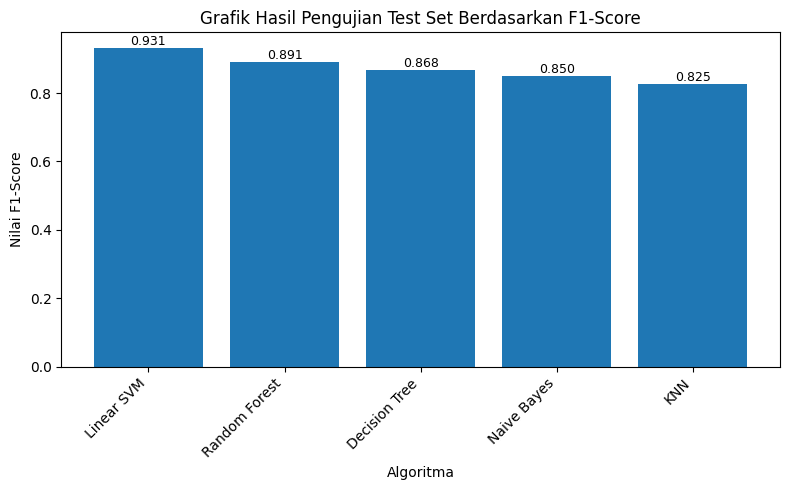

In [ ]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    df_test_results['Algoritma'],
    df_test_results['Test_F1-Score']
)

plt.title('Grafik Hasil Pengujian Test Set Berdasarkan F1-Score')
plt.xlabel('Algoritma')
plt.ylabel('Nilai F1-Score')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()


In [ ]:
best_model_name = cv_df.iloc[0]["Algoritma"]
best_model = models[best_model_name]

final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**TFIDF_CONFIG)),
    ("clf", best_model)
])

final_pipeline.fit(X_train, y_train)
y_test_pred = final_pipeline.predict(X_test)

print(f"\nMODEL TERBAIK: {best_model_name}")
print(classification_report(y_test, y_test_pred))



MODEL TERBAIK: Linear SVM
              precision    recall  f1-score   support

    NEGATIVE       0.75      0.67      0.71       100
    POSITIVE       0.95      0.97      0.96       714

    accuracy                           0.93       814
   macro avg       0.85      0.82      0.84       814
weighted avg       0.93      0.93      0.93       814



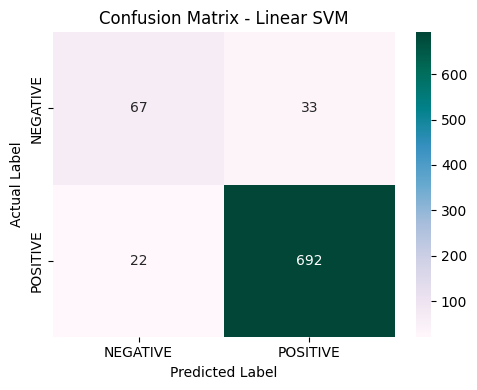

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["NEGATIVE", "POSITIVE"]

cm_test = confusion_matrix(
    y_test,
    y_test_pred,
    labels=labels
)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='PuBuGn',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

In [ ]:
df_test_result = pd.DataFrame({
    "Teks": X_test,
    "Label_Aktual": y_test,
    "Label_Prediksi": y_test_pred
})

df_test_result.to_csv("hasil_test_set.csv", index=False)


In [ ]:
from IPython.display import display

df_misclassified = df_test_result[
    df_test_result["Label_Aktual"] != df_test_result["Label_Prediksi"]
]

print("JUMLAH DATA SALAH KLASIFIKASI:", len(df_misclassified))

display(df_misclassified.head(10))

df_misclassified.to_csv("ulasan_salah_klasifikasi.csv", index=False)


JUMLAH DATA SALAH KLASIFIKASI: 55


,Teks,Label_Aktual,Label_Prediksi
20,aplikasi lumayan kadang akurat lapor sukses pu...,NEGATIVE,POSITIVE
39,selamat tinggal portal pulsa,NEGATIVE,POSITIVE
53,min saldo kurang modal aja kmbali gmna ni min,NEGATIVE,POSITIVE
79,klo harga jng klo yg bsa pda pindah hati,NEGATIVE,POSITIVE
83,aplikasi bagus langsung cetak struk jg cm sara...,POSITIVE,NEGATIVE
111,transaksi lelet error,POSITIVE,NEGATIVE
118,komplain selesai komplain tunggu,POSITIVE,NEGATIVE
120,bagus sih cs ramah yg mngecewakan sedia fitur ...,NEGATIVE,POSITIVE
177,jual pulsa tulis nomer pilih nominal nunggu nk...,NEGATIVE,POSITIVE
182,aplikasi simpel mas aja transaksi web aplikasi,NEGATIVE,POSITIVE


In [ ]:
df_misclassified.head(5)

,Teks,Label_Aktual,Label_Prediksi
20,aplikasi lumayan kadang akurat lapor sukses pu...,NEGATIVE,POSITIVE
39,selamat tinggal portal pulsa,NEGATIVE,POSITIVE
53,min saldo kurang modal aja kmbali gmna ni min,NEGATIVE,POSITIVE
79,klo harga jng klo yg bsa pda pindah hati,NEGATIVE,POSITIVE
83,aplikasi bagus langsung cetak struk jg cm sara...,POSITIVE,NEGATIVE


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model_testset(model_name, model, X_train, y_train, X_test, y_test):
    labels = ["NEGATIVE", "POSITIVE"]

    pipeline = Pipeline([
      ("tfidf", TfidfVectorizer(**TFIDF_CONFIG)),
        ("clf", model)
    ])


    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print("\n" + "="*60)
    print(f"EVALUASI TEST SET: {model_name}")
    print("="*60)
    print(classification_report(
        y_test,
        y_pred,
        labels=labels,
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='PuBuGn',
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    return y_pred

akhir


EVALUASI TEST SET: Naive Bayes
              precision    recall  f1-score   support

    NEGATIVE       1.00      0.11      0.20       100
    POSITIVE       0.89      1.00      0.94       714

    accuracy                           0.89       814
   macro avg       0.94      0.56      0.57       814
weighted avg       0.90      0.89      0.85       814



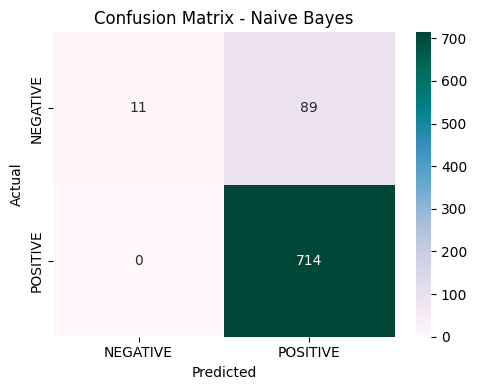


EVALUASI TEST SET: Random Forest
              precision    recall  f1-score   support

    NEGATIVE       0.82      0.33      0.47       100
    POSITIVE       0.91      0.99      0.95       714

    accuracy                           0.91       814
   macro avg       0.87      0.66      0.71       814
weighted avg       0.90      0.91      0.89       814



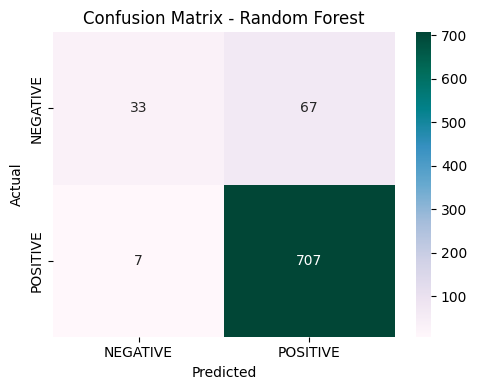


EVALUASI TEST SET: KNN
              precision    recall  f1-score   support

    NEGATIVE       0.67      0.02      0.04       100
    POSITIVE       0.88      1.00      0.94       714

    accuracy                           0.88       814
   macro avg       0.77      0.51      0.49       814
weighted avg       0.85      0.88      0.82       814



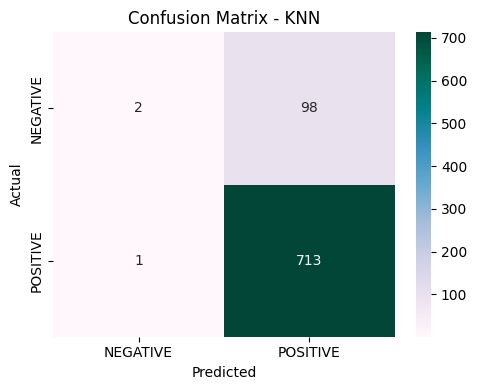


EVALUASI TEST SET: Decision Tree
              precision    recall  f1-score   support

    NEGATIVE       0.50      0.36      0.42       100
    POSITIVE       0.91      0.95      0.93       714

    accuracy                           0.88       814
   macro avg       0.71      0.65      0.67       814
weighted avg       0.86      0.88      0.87       814



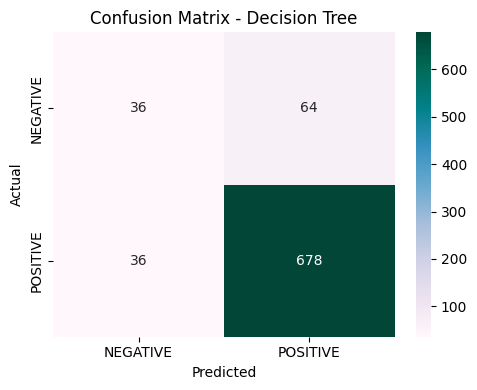

In [ ]:
for name, model in models.items():
    if name != "Linear SVM":   # kecuali model terbaik
        evaluate_model_testset(
            name,
            model,
            X_train, y_train,
            X_test, y_test
        )


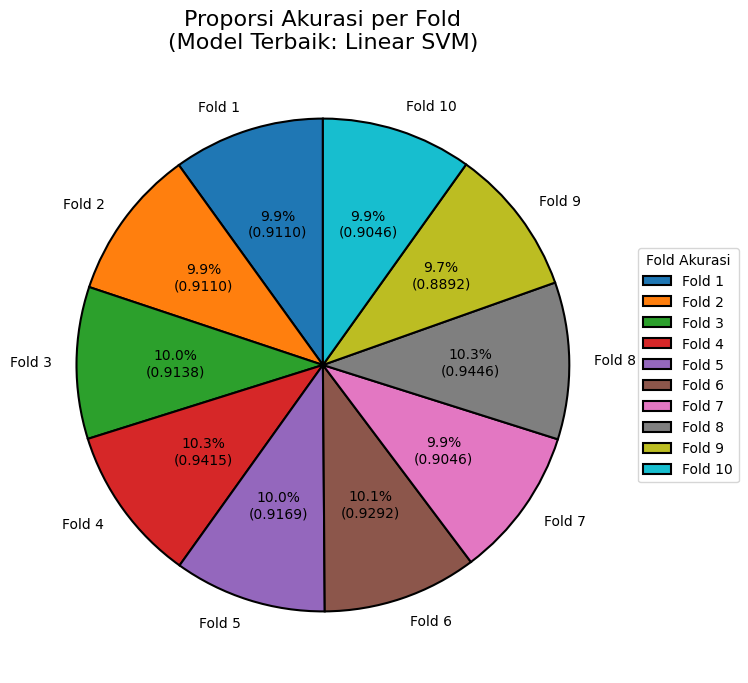

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

best_model_name = cv_df.iloc[0]['Algoritma']
best_model_accuracies = all_fold_accuracies[best_model_name]

labels = [f'Fold {i+1}' for i in range(len(best_model_accuracies))]
sizes = np.array(best_model_accuracies) * 100

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = (pct*total/100.0) /
        return f"{pct:.1f}%\n({val:.4f})"
    return my_autopct

plt.figure(figsize=(10, 8))
plt.pie(
    sizes,
    labels=labels,
    autopct=make_autopct(sizes),
    startangle=90,
    colors=plt.cm.tab10.colors,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
)

plt.title(f'Proporsi Akurasi per Fold\n(Model Terbaik: {best_model_name})', fontsize=16)

plt.legend(
    title="Fold Akurasi",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.show()

In [ ]:
def generate_appendix_v2(df, n_samples=5, max_words=7):
    """
    n_samples: jumlah baris yang diambil
    max_words: jumlah kata maksimal yang ditampilkan agar tidak terlalu panjang
    """
    appendix_list = []
    samples = df.head(n_samples).copy()

    for _, row in samples.iterrows():

        full_text = str(row['content'])
        words_split = full_text.split()
        if len(words_split) > max_words:
            truncated_text = ' '.join(words_split[:max_words]) + "..."
        else:
            truncated_text = full_text

        cf_step = apply_casefolding(truncated_text)
        cleaning_step = apply_cleaning_only(cf_step)
        case_folding_step = apply_casefolding(cleaning_step)
        no_punct = apply_punctuation_removal(case_folding_step)
        tokens = apply_tokenizing(no_punct)
        normalized = normalize_words(tokens)
        no_stopwords = remove_stopwords(normalized)
        stemmed = apply_stemming(no_stopwords)

        appendix_list.append({
            'Review Text': truncated_text,
            'Cleaning': cleaning_step,
            'Case Folding': case_folding_step,
            'Tokenize': tokens,
            'Stopword Removal': no_stopwords,
            'Stemming Data': ' '.join(stemmed),
            'Labeling': row['label']
        })

    return pd.DataFrame(appendix_list)

# Eksekusi dengan batas 10-15 kata saja per kolom
df_lampiran = generate_appendix_v2(df_final, n_samples=50, max_words=7)
display(df_lampiran)

,Review Text,Cleaning,Case Folding,Tokenize,Stopword Removal,Stemming Data,Labeling
0,"mantap,udah 3 tahun pake portal pulsa","mantap,udah tahun pake portal pulsa","mantap,udah tahun pake portal pulsa","[mantap, udah, tahun, pake, portal, pulsa]","[mantap, udah, pake, portal, pulsa]",mantap udah pake portal pulsa,POSITIVE
1,untuk pelayanan tagihan bulanan sejauh ini Uda...,untuk pelayanan tagihan bulanan sejauh ini uda.,untuk pelayanan tagihan bulanan sejauh ini uda.,"[untuk, pelayanan, tagihan, bulanan, sejauh, i...","[pelayanan, tagihan, bulanan]",layan tagih bulan,POSITIVE
2,Aplikasi PORTALPULSA sangat menguntungkan bagi...,aplikasi portalpulsa sangat menguntungkan bagi...,aplikasi portalpulsa sangat menguntungkan bagi...,"[aplikasi, portalpulsa, sangat, menguntungkan,...","[aplikasi, portalpulsa, menguntungkan, terima ...",aplikasi portalpulsa untung terima kasih aplikasi,POSITIVE
3,"Sudah 5 tahun jadi member, dan selama...","sudah tahun jadi member, dan selama.","sudah tahun jadi member, dan selama.","[sudah, tahun, jadi, member, dan, selama]",[member],member,NEGATIVE
4,aplikasi sangat bagus cepat deposit dan pengis...,aplikasi sangat bagus cepat deposit dan pengis...,aplikasi sangat bagus cepat deposit dan pengis...,"[aplikasi, sangat, bagus, cepat, deposit, dan,...","[aplikasi, bagus, cepat, deposit, pengisian]",aplikasi bagus cepat deposit isi,POSITIVE
5,"top markotop. jadi member sdah lebih 5tahun,...","top markotop. jadi member sdah lebih tahun,.","top markotop. jadi member sdah lebih tahun,.","[top, markotop, jadi, member, sdah, lebih, tahun]","[top, markotop, member, sdah]",top markotop member sdah,POSITIVE
6,mantap,mantap,mantap,[mantap],[mantap],mantap,POSITIVE
7,isi pulsa lama masuk,isi pulsa lama masuk,isi pulsa lama masuk,"[isi, pulsa, lama, masuk]","[isi, pulsa, masuk]",isi pulsa masuk,NEGATIVE
8,sekarang udh ada pembatasan saldo 30% setiap...,sekarang udh ada pembatasan saldo % setiap.,sekarang udh ada pembatasan saldo % setiap.,"[sekarang, udh, ada, pembatasan, saldo, setiap]","[pembatasan, saldo]",batas saldo,NEGATIVE
9,harga pulsa murah dan cepat masuknya,harga pulsa murah dan cepat masuknya,harga pulsa murah dan cepat masuknya,"[harga, pulsa, murah, dan, cepat, masuknya]","[harga, pulsa, murah, cepat, masuknya]",harga pulsa murah cepat masuk,POSITIVE
